In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import joblib

In [2]:
df = pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# Data cleaning

In [4]:
# Remove customer id
df = df.dropna(subset=['CustomerID'])

In [5]:
# Remove duplicate rows
df = df.drop_duplicates()

In [6]:
# Remove cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [7]:
# Remove negative quantities
df = df[df['Quantity'] > 0]

In [8]:
# Remove negative or zero price
df = df[df['UnitPrice'] > 0]

# Feature Preparation

In [9]:
# Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [10]:
# Create Total Amount
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# RFM Features

In [11]:
# snapshot date
snapshot_date = df['InvoiceDate'].max()

In [12]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [13]:
rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']

In [14]:
# remove extreme outliers
rfm = rfm[rfm['Monetary'] < rfm['Monetary'].quantile(0.99)]

In [15]:
X = rfm[['Recency', 'Frequency', 'AOV']]
y = rfm['Monetary']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [19]:
y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 52.132140546645495
RMSE: 214.48606199370212


# Feature Importance Plot

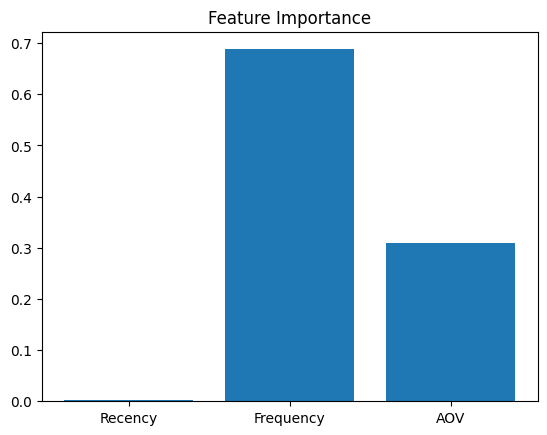

In [20]:
importances = xgb_model.feature_importances_
features = X.columns

plt.bar(features, importances)
plt.title("Feature Importance")
plt.show()

# Predict LTV for all Customers

In [21]:
rfm['Predicted_LTV'] = xgb_model.predict(X)

In [22]:
# Segment Customers
rfm['Segment'] = pd.qcut(
    rfm['Predicted_LTV'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

In [23]:
rfm.to_csv("Final_LTV_Predictions.csv", index=False)

In [25]:
joblib.dump(xgb_model, "ltv_model.pkl")

['ltv_model.pkl']

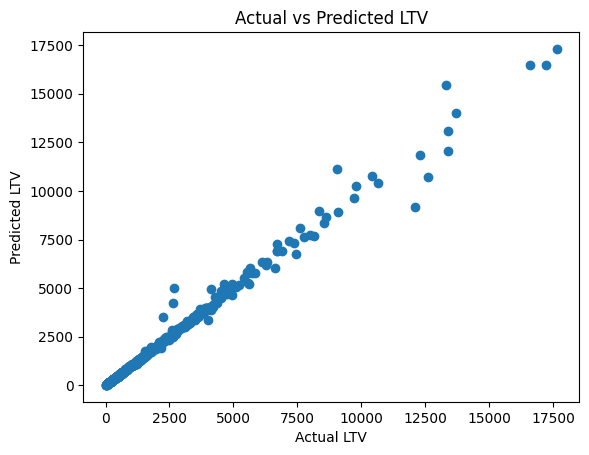

In [26]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual LTV")
plt.ylabel("Predicted LTV")
plt.title("Actual vs Predicted LTV")
plt.show()